## Chapter3 - What to Cover Next?

- Loading and processing data
- Building the model
- Defining the loss function
- Defining the optimizer
- Training and transfer learning
- Deploying the model

STL-10 dataset will be used for demonstration. The images are RGB color with a size of 96*96. The dataset contains 5,000 training images
and 8,000 test images. There are 500 and 800 images per class in the training and test
datasets, respectively.

Labels are:
- Airplane: 0
- Bird: 1
- Car: 2
- Cat: 3
- Deer: 4
- Dog: 5
- Horse: 6
- Monkey: 7
- Ship: 8
- Truck: 9

In [1]:
from torch.utils.data import Subset
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision import utils

from sklearn.model_selection import StratifiedShuffleSplit

import numpy as np
import collections
import os

import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)

In [2]:
path2data="./data"

if not os.path.exists(path=path2data):
    os.mkdir(path=path2data)

data_transformer = transforms.Compose([transforms.ToTensor()])
train_ds=datasets.STL10(path2data, split='train', download=True, transform=data_transformer)

print(train_ds.data.shape)

Files already downloaded and verified
(5000, 3, 96, 96)


In [3]:
y_train=[y for _,y in train_ds]
counter_train=collections.Counter(y_train)
print(counter_train)

Counter({1: 500, 5: 500, 6: 500, 3: 500, 9: 500, 7: 500, 4: 500, 8: 500, 0: 500, 2: 500})


In [4]:
test0_ds=datasets.STL10(path2data, split='test',download=True,transform=data_transformer)
print(test0_ds.data.shape)

Files already downloaded and verified
(8000, 3, 96, 96)


In [5]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

indices=list(range(len(test0_ds)))
y_test0=[y for _,y in test0_ds]

for test_index, val_index in sss.split(indices,y_test0):
    print("test: {}\ntest lenght: {}".format(test_index,len(test_index)))
    print("val: {}\nval lenght: {}".format(val_index,len(val_index)))

test: [ 369 4826 7056 ... 1150 6669  351]
test lenght: 6400
val: [4311 4042 1350 ...  703   97 4926]
val lenght: 1600


In [6]:
val_ds=Subset(test0_ds,val_index)
test_ds=Subset(test0_ds,test_index)

In [7]:
y_test=[y for _,y in test_ds]
y_val=[y for _,y in val_ds]

counter_test=collections.Counter(y_test)
counter_val=collections.Counter(y_val)

print("Test-Number of images per label: ",counter_test)
print("Val-Number of images per label:  ",counter_val)


Test-Number of images per label:  Counter({2: 640, 6: 640, 1: 640, 8: 640, 0: 640, 9: 640, 4: 640, 5: 640, 7: 640, 3: 640})
Val-Number of images per label:   Counter({8: 160, 5: 160, 9: 160, 3: 160, 0: 160, 1: 160, 6: 160, 2: 160, 7: 160, 4: 160})


In [8]:
def show(img, label, color=False):
    npimg=img.numpy()
    
    # Change shape C*H*W to H*W*C 
    npimg_transpose = np.transpose(npimg, (1,2,0))

    if color == False:
        npimg_transpose = npimg_transpose[:,:,0]
        plt.imshow(npimg_transpose, interpolation='nearest', cmap='gray')
    else:
        plt.imshow(npimg_transpose, interpolation='nearest')

    plt.title("Label: "+ str(label))
    plt.show()

In [9]:
# Creating sample images in grid
grid_size = 4
random_indice = np.random.randint(0, len(train_ds), grid_size)
print("Randomly selected image indices: ",random_indice)

x_grid_train = [train_ds[i][0] for i in random_indice]
[print(train_ds[i][1]) for i in random_indice]
y_grid_train = [train_ds[i][1] for i in random_indice]

x_grid_train=utils.make_grid(x_grid_train, nrow=4, padding=2)
print(x_grid_train.shape)

Randomly selected image indices:  [ 860 3772 3092  466]
6
9
0
0
torch.Size([3, 100, 394])


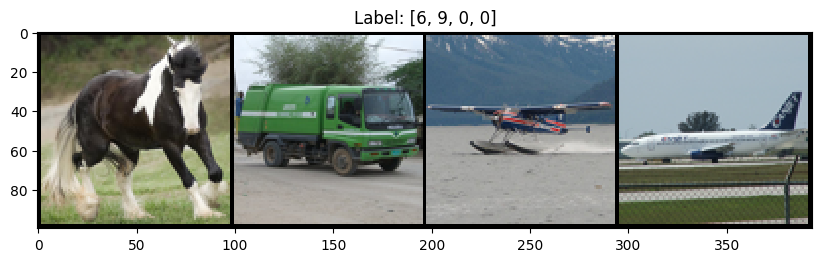

In [10]:
plt.rcParams['figure.figsize'] = (10.0, 5)
show(x_grid_train,y_grid_train, color=True)